# Converting a mesh between formats with meshio++

meshio++ converts one in-memory `Mesh` to any of its 35+ formats. Here we
take the bracket geometry from `example.msh` and write it to several
formats, compare the resulting file sizes, and verify the round trip.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

import meshioplusplus as mp

EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')  # when run from example/python/ with a different cwd

src = mp.read(EXAMPLE)
# Keep the portable geometry (surface triangles + solid tetrahedra); the
# original file also carries per-entity vertex/line groups and gmsh tags.
tri = np.concatenate([cb.data for cb in src.cells if cb.type == 'triangle'])
tet = np.concatenate([cb.data for cb in src.cells if cb.type == 'tetra'])
mesh = mp.Mesh(src.points, [('triangle', tri), ('tetra', tet)])
print(f'{len(mesh.points):,} points, {len(tri):,} triangles, {len(tet):,} tetrahedra')

52,282 points, 58,394 triangles, 235,014 tetrahedra


## Convert to several formats

In [2]:
tmpdir = tempfile.mkdtemp()

# (label, filename, write kwargs)
targets = [
    ('vtu (ascii)',       'mesh_ascii.vtu', dict(binary=False)),
    ('vtu (binary+zlib)', 'mesh.vtu',       dict(binary=True)),
    ('vtk (binary)',      'mesh.vtk',       dict(binary=True)),
    ('xdmf',              'mesh.xdmf',      {}),
    ('gmsh (binary)',     'mesh.msh',       dict(binary=True, file_format='gmsh')),
    ('ply (binary)',      'mesh.ply',       dict(binary=True)),
]

def total_size(path):
    # XDMF writes a companion .h5; count the sidecar too.
    size = os.path.getsize(path)
    h5 = os.path.splitext(path)[0] + '.h5'
    if path.endswith('.xdmf') and os.path.exists(h5):
        size += os.path.getsize(h5)
    return size

results = []
for label, fn, kw in targets:
    path = os.path.join(tmpdir, fn)
    mesh.write(path, **kw)
    mb = total_size(path) / 1e6
    results.append((label, path, kw, mb))
    print(f'{label:20s} {mb:7.2f} MB')

vtu (ascii)            12.31 MB
vtu (binary+zlib)       4.76 MB
vtk (binary)           13.70 MB


xdmf                    3.41 MB
gmsh (binary)          12.94 MB


ply (binary)            1.46 MB


meshio warning [ply.cpp:408] PLY: writing the extracted skin of the volume cells; 1 pre-existing non-volume cell block(s) dropped (pass skin=false for the legacy behavior).


## Physics-ML export targets

Four of meshio++'s formats exist to feed a training pipeline rather than
another mesh tool: `pmsh` and `zarr` write the two layouts NVIDIA
PhysicsNeMo's own `MeshDataset` reads, `cae` writes the per-case `.npz`
sample its DoMINO and Transolver datapipes read, and `usd` writes a
time-sampled OpenUSD stage. The first three are lossy by design — each
reduces a mesh to what its consumer's data model holds — so they warn about
what they dropped rather than doing it quietly.

`pmsh` and `zarr` hold exactly one simplex kind, so the bracket's triangles
and tetrahedra cannot both survive: the tetrahedra win and the reduction is
reported.

In [3]:
# One simplex kind per file: the surface triangles are dropped with a warning.
pmsh_path = os.path.join(tmpdir, 'bracket.pmsh')
mp.write(pmsh_path, mesh)
back = mp.read(pmsh_path)
print(f'pmsh  -> {len(back.points):,} points, '
      f'{[(b.type, len(b.data)) for b in back.cells]}, '
      f'memory-mapped: {isinstance(back.points.base, np.memmap)}')

if mp.has_zarr():
    zarr_path = os.path.join(tmpdir, 'bracket.zarr')
    mp.write(zarr_path, mesh)
    print(f'zarr  -> {len(mp.read(zarr_path).points):,} points')

# The CAE sample: the solid's skin, triangulated, plus its nodes and fields.
field = mesh.points[:, 2]
sample = mp.Mesh(mesh.points, [('tetra', tet)], point_data={'height': field})
npz_path = os.path.join(tmpdir, 'case_0.npz')
mp.cae.write(npz_path, sample, global_params={'stream_velocity': 30.0}, time=0.0, step=0)

with np.load(npz_path) as data:
    for key in ('stl_coordinates', 'stl_faces', 'stl_areas', 'surface_normals',
                'surface_fields', 'volume_mesh_centers', 'volume_fields'):
        print(f'{key:22s} {str(data[key].dtype):8s} {data[key].shape}')
    print(f'total surface area {float(data["stl_areas"].sum()):.4f}')

Warning: pmsh: physicsnemo.mesh.Mesh is single-manifold-dim; dropped triangle x 58394 -- export each dimension as 
its own Mesh

pmsh  -> 52,282 points, [('tetra', 235014)], memory-mapped: True


stl_coordinates        float32  (29151, 3)
stl_faces              int32    (175182,)
stl_areas              float32  (58394,)
surface_normals        float32  (58394, 3)
surface_fields         float32  (58394, 1)
volume_mesh_centers    float32  (52282, 3)
volume_fields          float32  (52282, 1)
total surface area 20.8405


### The exported surface, rendered

`cae.read` gives the surface half back as a triangle mesh whose `cell_data`
carries the normals, areas and the named field blocks split back apart — so
the thing the training pipeline will actually see can be looked at directly.
Coloured here by `height`, the nodal field the exporter averaged onto each
triangle from its three vertices.

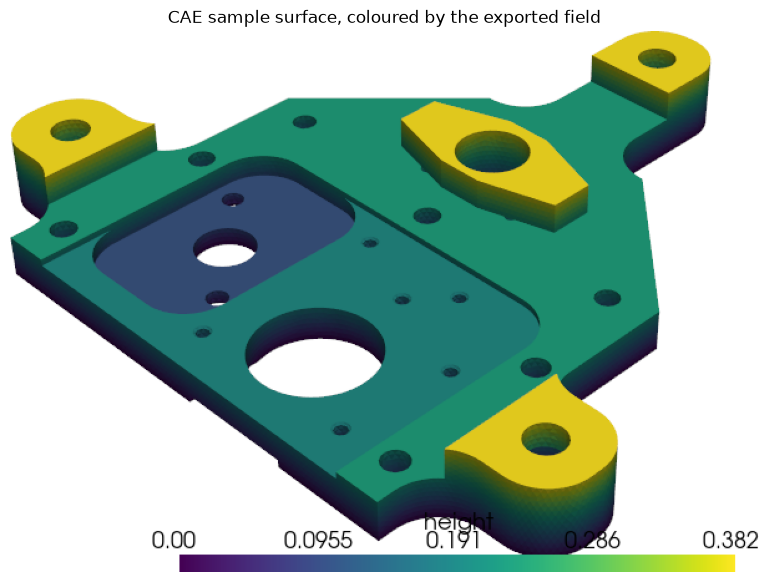

In [4]:
surface = mp.cae.read(npz_path)          # the surface half
height = surface.cell_data['height'][0]

def crop_white(img, tol=250):
    # The renderer pads its viewport; trim the uniform border so the part
    # fills the figure instead of floating in it.
    mask = (img[:, :, :3] < tol).any(axis=2)
    rows, cols = np.where(mask.any(axis=1))[0], np.where(mask.any(axis=0))[0]
    if not len(rows) or not len(cols):
        return img
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

try:
    import pyvista as pv

    pv.OFF_SCREEN = True
    vtp = os.path.join(tmpdir, 'surface.vtp')
    mp.write(vtp, mp.Mesh(surface.points, surface.cells,
                          cell_data={'height': [height]}))
    grid = pv.read(vtp)
    plotter = pv.Plotter(off_screen=True, window_size=(900, 620))
    plotter.add_mesh(grid, scalars='height', cmap='viridis', show_edges=False,
                     scalar_bar_args=dict(title='height', vertical=False,
                                          position_x=0.25, position_y=0.02,
                                          width=0.5, height=0.06))
    plotter.view_isometric()
    plotter.camera.zoom(1.4)
    img = crop_white(plotter.screenshot(return_img=True))
    plotter.close()

    fig, ax = plt.subplots(figsize=(8.2, 8.2 * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('CAE sample surface, coloured by the exported field')
    plt.tight_layout()
    plt.show()
except Exception as exc:  # head-less GL, or no PyVista
    print(f'PyVista render unavailable ({exc}); showing the distribution instead')
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(height, bins=60, color='#3987e5')
    ax.set_xlabel('height')
    ax.set_ylabel('triangles')
    ax.set_title('CAE sample surface: exported field distribution')
    plt.tight_layout()
    plt.show()

## VTKHDF: time and partitions in one file

`.vtkhdf` is Kitware's HDF5-based VTK format, and the one ParaView format that
keeps a whole transient case in a single file: the geometry is written **once**,
every field is an extendable dataset, and a small `Steps` table says which slice
belongs to which time. A run that would otherwise leave `wave_0000.vtu …
wave_0500.vtu` behind is one file with random access per step.

`TimeSeriesWriter` streams the steps in as they are produced (nothing is
buffered, so a killed run still leaves a file ParaView opens). Here a wave
travels along the bracket; the `.vtu` alternative stores the geometry again for
every step.

In [5]:
from meshioplusplus.vtkhdf import TimeSeriesWriter

# A wave travelling along x, sampled at six instants. The geometry goes in once.
x = mesh.points[:, 0]
x = (x - x.min()) / (x.max() - x.min())
times = np.linspace(0.0, 1.0, 6)

series = os.path.join(tmpdir, 'wave.vtkhdf')
with TimeSeriesWriter(series, compression='gzip') as writer:
    writer.write_points_cells(mesh.points, mesh.cells)
    for t in times:
        writer.write_data(t, point_data={'wave': np.sin(2 * np.pi * (x - t))})

meta = mp.read_metadata(series)
print('steps       :', len(meta['time_values']), meta['time_values'])

# The same run the way the XML formats store it: one .vtu per step.
per_step = 0
for k, t in enumerate(times):
    m = mp.Mesh(mesh.points, mesh.cells,
                point_data={'wave': np.sin(2 * np.pi * (x - t))})
    path = os.path.join(tmpdir, f'wave_{k}.vtu')
    mp.write(path, m, binary=True)
    per_step += os.path.getsize(path)
one_file = os.path.getsize(series)
print(f'{len(times)} .vtu files: {per_step / 1e6:.2f} MB   one .vtkhdf: {one_file / 1e6:.2f} MB')

steps       : 6 [0.0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0]
6 .vtu files: 30.51 MB   one .vtkhdf: 5.04 MB


`read(..., time_step=k)` reads one step out of the file, not all six, and
attaches its time as `field_data['meshio:time']`. Negative `k` counts from the
end. The three steps below are three separate reads of the same file.

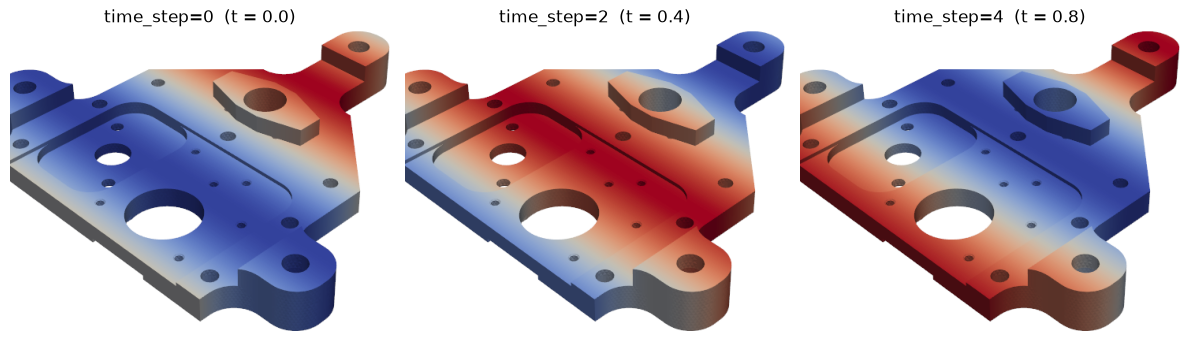

In [6]:
picked = [0, 2, 4]

def render_step(k):
    """Read one step straight out of the file and draw it, or return None without a GL context."""
    import pyvista as pv

    pv.OFF_SCREEN = True
    step = mp.read(series, time_step=k)          # a hyperslab of the file, not all six steps
    grid = mp.to_pyvista(step)
    plotter = pv.Plotter(off_screen=True, window_size=(600, 520))
    plotter.add_mesh(grid, scalars='wave', cmap='coolwarm', clim=(-1, 1), show_scalar_bar=False)
    plotter.view_isometric()
    plotter.camera.zoom(1.5)
    img = crop_white(plotter.screenshot(return_img=True))
    plotter.close()
    return img, float(step.field_data['meshio:time'][0])

fig, axes = plt.subplots(1, len(picked), figsize=(12, 4.2))
try:
    for ax, k in zip(axes, picked):
        img, t = render_step(k)
        ax.imshow(img)
        ax.set_title(f'time_step={k}  (t = {t:.1f})')
        ax.axis('off')
except Exception as exc:  # head-less GL, or no PyVista
    print(f'PyVista render unavailable ({exc}); drawing the x-y projection instead')
    for ax, k in zip(axes, picked):
        step = mp.read(series, time_step=k)
        ax.scatter(step.points[:, 0], step.points[:, 1], c=step.point_data['wave'],
                   s=2, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_title(f'time_step={k}')
        ax.set_aspect('equal')
        ax.axis('off')
plt.tight_layout()
plt.show()

### Partitions and composite blocks

A `PartitionedDataSetCollection` holds several named pieces in one file, the
single-file equivalent of a `.vtm` with its `.vtu` children. Cell regions become
the blocks on write. On read the pieces are merged into one mesh with one region
per piece, or `piece=k` picks a single one (negative counts from the end, and
`read_metadata` reports how many there are).

In [7]:
# Split the tetrahedra into three slabs along x and name each one as a cell region.
centroid_x = mesh.points[tet].mean(axis=1)[:, 0]
edges = np.quantile(centroid_x, [0, 1 / 3, 2 / 3, 1])
slab_of = np.clip(np.searchsorted(edges, centroid_x, side='right') - 1, 0, 2)
partitioned = mp.Mesh(mesh.points, [('tetra', tet)],
                      regions=[mp.Region(f'slab_{i}', 'cell', np.flatnonzero(slab_of == i),
                                         dim=3, tag=i) for i in range(3)])

pieces = os.path.join(tmpdir, 'slabs.vtkhdf')
mp.write(pieces, partitioned, dataset_type='PartitionedDataSetCollection')

merged = mp.read(pieces)                     # every block in one mesh, one region per block
print('merged  :', sum(len(cb.data) for cb in merged.cells), 'tetrahedra,',
      [(r.name, len(r.entries)) for r in sorted(merged.regions, key=lambda r: r.tag)])
one = mp.read(pieces, piece=1)               # a single block, as a mesh of its own
print('piece=1 :', sum(len(cb.data) for cb in one.cells), 'tetrahedra')
print('piece=-1:', sum(len(cb.data) for cb in mp.read(pieces, piece=-1).cells), 'tetrahedra')

merged  : 235014 tetrahedra, [('slab_0', 78338), ('slab_1', 78338), ('slab_2', 78338)]
piece=1 : 78338 tetrahedra
piece=-1: 78338 tetrahedra


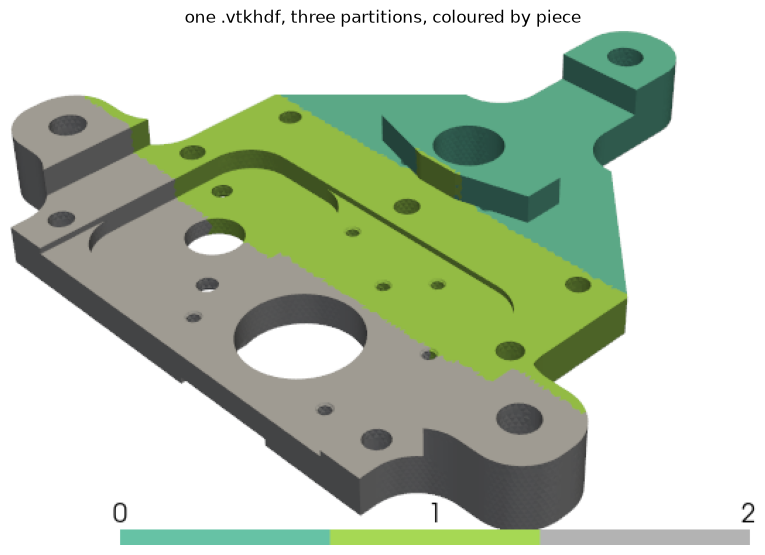

In [8]:
# Colour the merged mesh by the piece each cell came from.
n_cells = sum(len(cb.data) for cb in merged.cells)
piece_of = np.zeros(n_cells, dtype=np.int32)
for r in merged.regions:
    piece_of[r.entries] = r.tag
coloured = mp.Mesh(merged.points, merged.cells, cell_data={'piece': [piece_of]})

try:
    import pyvista as pv

    pv.OFF_SCREEN = True
    plotter = pv.Plotter(off_screen=True, window_size=(900, 520))
    plotter.add_mesh(mp.to_pyvista(coloured), scalars='piece', cmap='Set2', n_colors=3,
                     scalar_bar_args=dict(title=' ', vertical=False, n_labels=3, fmt='%.0f',
                                          position_x=0.25, position_y=0.02, width=0.5,
                                          height=0.06))
    plotter.view_isometric()
    plotter.camera.zoom(1.4)
    img = crop_white(plotter.screenshot(return_img=True))
    plotter.close()

    fig, ax = plt.subplots(figsize=(8.2, 8.2 * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('one .vtkhdf, three partitions, coloured by piece')
    plt.tight_layout()
    plt.show()
except Exception as exc:  # head-less GL, or no PyVista
    print(f'PyVista render unavailable ({exc}); drawing the x-y projection instead')
    centres = merged.points[np.concatenate([cb.data for cb in merged.cells])].mean(axis=1)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.scatter(centres[:, 0], centres[:, 1], c=piece_of, s=2, cmap='Set2')
    ax.set_aspect('equal')
    ax.set_title('one .vtkhdf, three partitions, coloured by piece')
    plt.tight_layout()
    plt.show()

## `.pvtu` and `.pvd`: the same ideas as ParaView's own index files

VTKHDF keeps a partitioned, transient case in one file. The XML formats do it with **index files**: a `.pvtu` declares the arrays and names one `.vtu` piece per *part*, and a `.pvd` is a time-indexed list of files. Both are what ParaView writes for a parallel run, and both are what `partition` and the sequence engine now produce directly.

`partition` returns one mesh per part. With `ghost_layers=1` each part also carries the neighbouring cells it needs, a halo, tagged `partition:ghost`. `pvtu.write_pieces` writes the parts as they are and translates the tag into VTK's own `vtkGhostType` (cells and points) and the index's `GhostLevel`.

In [9]:
solid = mp.Mesh(mesh.points, [('tetra', tet)])
parts = mp.partition(solid, 3, method='sfc', ghost_layers=1)

index = os.path.join(tmpdir, 'bracket.pvtu')
mp.pvtu.write_pieces(index, parts)          # bracket.pvtu + bracket/bracket_0000.vtu ...
print('pieces on disk :', sorted(os.listdir(os.path.join(tmpdir, 'bracket'))))
print('index          :', [ln for ln in open(index).read().splitlines() if 'GhostLevel' in ln][0])

def n_cells(m):
    return sum(len(cb.data) for cb in m.cells)

kept = mp.read(index)                  # the halo is real data: more cells than the original
dropped = mp.read(index, ghosts='drop')  # the partition of unity again
print(f'original {n_cells(solid):,} cells | with halos {n_cells(kept):,} | ghosts dropped {n_cells(dropped):,}')
print('regions        :', [(r.name, len(r.entries)) for r in dropped.regions])

# Pieces duplicate the points on a part boundary; welding fuses them: the original mesh, up to point ordering.
whole = mp.clean(dropped, weld=True)
print(f'welded points  : {len(whole.points):,}  (the solid has {len(np.unique(tet)):,})')

pieces on disk : ['bracket_0000.vtu', 'bracket_0001.vtu', 'bracket_0002.vtu']
index          : <PUnstructuredGrid GhostLevel="1">
original 235,014 cells | with halos 255,353 | ghosts dropped 235,014
regions        : [('piece_0', 78338), ('piece_1', 78338), ('piece_2', 78338)]


welded points  : 52,282  (the solid has 52,282)


Reading the index merges the pieces into one mesh with one region per piece, or `piece=k` keeps a single part; `ghosts='drop'` (or `convert --drop-ghosts`) removes the halo on any read. Below, the first part on its own with its halo (the halo cells are the ones a neighbouring part owns), next to the whole solid rebuilt from the three parts with `ghosts='drop'`.

part 0: 78,338 owned cells + 5,144 halo cells


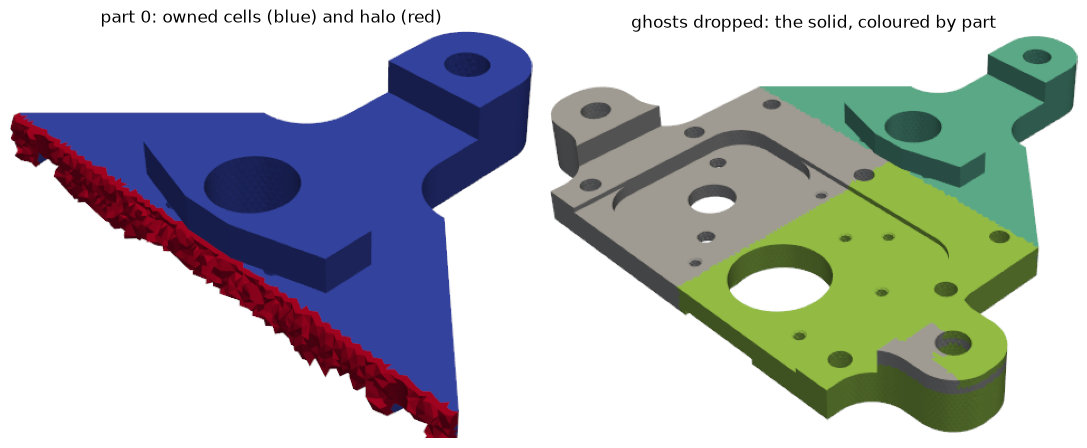

In [10]:
one_part = mp.read(index, piece=0)                     # part 0 and its one-layer halo
layer = one_part.cell_data['partition:ghost'][0]            # 0 = owned, 1 = reached at layer 1
print(f'part 0: {int((layer == 0).sum()):,} owned cells + {int((layer > 0).sum()):,} halo cells')

n = n_cells(dropped)
piece_of = np.zeros(n, dtype=np.int32)
for r in dropped.regions:
    piece_of[r.entries] = int(r.name.split('_')[1])
whole_by_piece = mp.Mesh(dropped.points, dropped.cells, cell_data={'piece': [piece_of]})
part_with_halo = mp.Mesh(one_part.points, one_part.cells, cell_data={'layer': [layer.astype(np.int32)]})

def draw(ax, m, name, cmap, title):
    import pyvista as pv

    pv.OFF_SCREEN = True
    plotter = pv.Plotter(off_screen=True, window_size=(700, 520))
    plotter.add_mesh(mp.to_pyvista(m), scalars=name, cmap=cmap, show_scalar_bar=False)
    plotter.view_isometric()
    plotter.camera.zoom(1.4)
    img = crop_white(plotter.screenshot(return_img=True))
    plotter.close()
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
try:
    draw(axes[0], part_with_halo, 'layer', 'coolwarm', 'part 0: owned cells (blue) and halo (red)')
    draw(axes[1], whole_by_piece, 'piece', 'Set2', 'ghosts dropped: the solid, coloured by part')
except Exception as exc:  # head-less GL, or no PyVista
    print(f'PyVista render unavailable ({exc}); drawing the x-z projection instead')
    for ax, (m, name, title) in zip(axes, [(part_with_halo, 'layer', 'part 0 and its halo'),
                                              (whole_by_piece, 'piece', 'the solid, coloured by part')]):
        ax.clear()
        centres = m.points[np.concatenate([cb.data for cb in m.cells])].mean(axis=1)
        ax.scatter(centres[:, 0], centres[:, 2], c=m.cell_data[name][0], s=2, cmap='coolwarm')
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.axis('off')
plt.tight_layout()
plt.show()

### A transient run as a `.pvd`

`write_sequence` to a `.pvd` streams one mesh at a time: each step is a `.vtu` next to the index and the index is rewritten after every step, so a run that dies still leaves a collection ParaView opens. The steps are the distinct `timestep=` values, so `read_metadata` reports them from the index without opening a single piece, and `time_step=` picks one.

steps          : [0.0, 0.2, 0.4, 0.6000000000000001, 0.8, 1.0] | a full read was needed: False
files          : ['run_0000.vtu', 'run_0001.vtu', 'run_0002.vtu', 'run_0003.vtu', 'run_0004.vtu', 'run_0005.vtu']
<DataSet timestep="0.2" part="0" file="run/run_0001.vtu"/>
time_step=-1   : t = 1.0


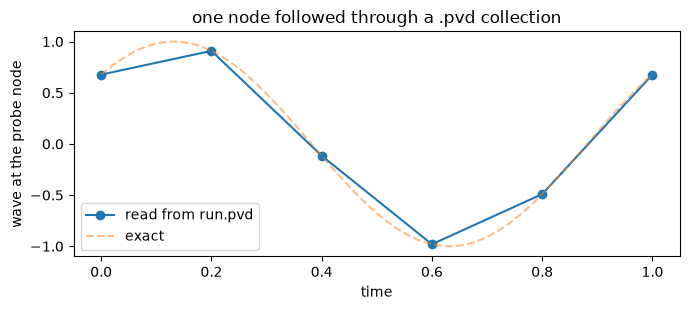

In [11]:
run = os.path.join(tmpdir, 'run.pvd')
mp.write_sequence(run, ((t, mp.Mesh(mesh.points, mesh.cells,
                                    point_data={'wave': np.sin(2 * np.pi * (x - t))}))
                        for t in times))

meta = mp.read_metadata(run)
print('steps          :', meta['time_values'], '| a full read was needed:', meta['fell_back_to_full_read'])
print('files          :', sorted(os.listdir(os.path.join(tmpdir, 'run'))))
print(open(run).read().split('<Collection>')[1].split('</Collection>')[0].strip().splitlines()[1])

last = mp.read(run, time_step=-1)           # the final state; its time comes back as field data
print('time_step=-1   : t =', float(last.field_data['meshio:time'][0]))

# Follow one node through the run, straight off the collection.
probe = int(np.argmax(mesh.points[:, 2]))
trace = [(t, float(m.point_data['wave'][probe])) for t, m in mp.read_sequence(run)]
ts, ys = zip(*trace)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ts, ys, 'o-', label='read from run.pvd')
tt = np.linspace(0, 1, 200)
ax.plot(tt, np.sin(2 * np.pi * (x[probe] - tt)), '--', alpha=0.5, label='exact')
ax.set_xlabel('time')
ax.set_ylabel('wave at the probe node')
ax.set_title('one node followed through a .pvd collection')
ax.legend()
plt.tight_layout()
plt.show()

## Compare file sizes

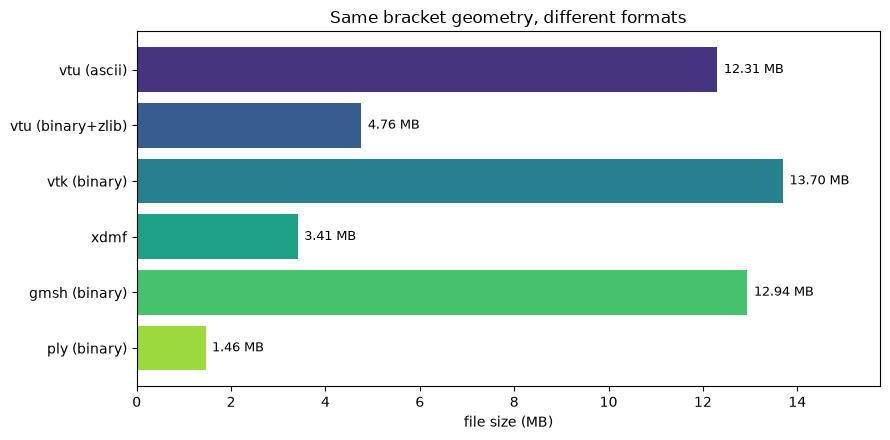

In [12]:
labels = [r[0] for r in results]
sizes = [r[3] for r in results]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(labels)))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, sizes, color=colors)
ax.invert_yaxis()
ax.set_xlabel('file size (MB)')
ax.set_title('Same bracket geometry, different formats')
for bar, mb in zip(bars, sizes):
    ax.text(bar.get_width() + max(sizes) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{mb:.2f} MB', va='center', fontsize=9)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Round-trip verification

Read every file back and check the counts survive.

In [13]:
n_pts = len(mesh.points)
n_cells = len(tri) + len(tet)
for label, path, kw, _ in results:
    back = mp.read(path, file_format=kw.get('file_format'))
    bpts = len(back.points)
    bcells = sum(len(cb.data) for cb in back.cells)
    ok = (bpts == n_pts) and (bcells == n_cells)
    status = 'OK ' if ok else 'DIFF'
    print(f'{status} {label:20s} points={bpts:,} cells={bcells:,}')

OK  vtu (ascii)          points=52,282 cells=293,408
OK  vtu (binary+zlib)    points=52,282 cells=293,408
OK  vtk (binary)         points=52,282 cells=293,408
OK  xdmf                 points=52,282 cells=293,408
OK  gmsh (binary)        points=52,282 cells=293,408
DIFF ply (binary)         points=29,151 cells=58,394


Every format round-trips the geometry. For the timing difference between
meshio++ and the original pure-Python meshio, see the
[benchmarks](../benchmark/01_benchmark.ipynb).